In [1]:
import os 
from typing import TypedDict,List,Literal
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage,SystemMessage



# langgraph
from langgraph.graph import START,END,StateGraph


# for Rag
from langchain_community.document_loaders import WebBaseLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings

# vector
from langchain_community.vectorstores import FAISS

# schema's 
from Models.OutputSchema import EvalulationScore, KnowledgeRefinementResult ,RewritenQwery,GeneratedResponce
from Utils.HelperFxns import text_to_sentence_converter

# for web search 
from tavily import TavilyClient

from dotenv import load_dotenv

load_dotenv()
os.environ[("OPENAI_API_KEY")]=os.getenv("OPENAI_API_KEY")
tavily=TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
model=init_chat_model("gpt-4o")

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
# load the documents from the Documents folder 
folder_path="./Documents"

def load_folder_pdf(folder_path:str):
    all_doc=[]
    for filename in os.listdir(folder_path):
        if filename.endswith(".pdf"):
            file_path=os.path.join(folder_path,filename)
            print(f"Loading: {filename}")
            
            loader=PyPDFLoader(file_path)
            docs=loader.load()
            all_doc.extend(docs)
    
    return all_doc

documents=load_folder_pdf(folder_path)
print(f"Loaded {len(documents)} documents")

Loading: Code_Agent_Final_Roadmap.pdf.pdf
Loading: DS -Intern Assignment .pdf
Loaded 37 documents


In [3]:
# split the doc into chunks
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)

chunks=text_splitter.split_documents(documents)

In [4]:
# init the embedding modle 
embedding=OpenAIEmbeddings(model="text-embedding-3-small")
vector_store=FAISS.from_documents(chunks,embedding)

# retriver
retriver=vector_store.as_retriever(search_type="similarity",search_kwargs={"k":4})

In [5]:
class App_State(TypedDict):
    user_question:str
    relivent_chunks:List[Document]
    
    # for  evaluator
    good_chunks:List[Document]
    evaluation_result:Literal["correct","incorrect","ambiguous"]
    
    # for refinement
    refined_sentences:List[str]
    refined_context:str
    
    # for rewrite qwery
    rewritten_qwery:str
    
    # for web search
    web_search_result:List[str]
    
    # final answers
    answer:str
    answergiven:bool
    
    # retry count
    curr_iter: int=0
    max_iter: int=3

In [14]:
# retrive the relevant chunks based on the user question
def retriveer_node(state:App_State):
    user_question=state["user_question"]
    print("retriver fxn has been caleed ")
    retrived_chunks=retriver.invoke(user_question)
    return {"relivent_chunks":retrived_chunks}

def reterival_eval_node(state:App_State):
    print("the retrival evaluation node has been called ")
    merit_score=8
    passing_score=4
    # here we will evaluate each retrived document to see if is corrent /incorrect or ambigours
    
    chunks=state["relivent_chunks"]
    good_chunks=[]
    eval_score=[]
    for chunk in chunks:
        sys_msg=SystemMessage(content="you are a evaluator. you have to see the question and check if the given context is able to answer that question and based on that  you will  give a score between 0 to 10 . ")
        human_msg=HumanMessage(content=f"give me the score Question->{state['user_question']} \n\n Context-> {chunk.page_content}")
        final_model=model.with_structured_output(EvalulationScore)
        res=final_model.invoke([sys_msg,human_msg])
        print("the out of eval llm ",res.score)
        eval_score.append(res.score)
        if(res.score>=passing_score):
            good_chunks.append(chunk)
    
    print(f"the eval score are {eval_score}")
    # set the evaluation result in the evaluation_result state
    if any(s>=merit_score for s in eval_score):
        state["evaluation_result"]="correct"
    elif all(s<passing_score for s in eval_score):
        state["evaluation_result"]="incorrect"
    else:
        state["evaluation_result"]="ambiguous"
    
    state["good_chunks"]=good_chunks
    return state

def knowledge_refinement_node(state:App_State):
    # in this node what we will do is we will split the chunk into sentences.and will keep only the sentences that are relivent
    # combine the whole doc into one string
    print("in the knowledge refinement node")
    combined_text = " "
    if(state["evaluation_result"]=="incorrect"):
        # if the retrieved doc is incorrect then we will use the web search result to refine the knowledge 
        for web_res in state["web_search_result"]:
            combined_text+=web_res+"\n\n"   
    elif(state["evaluation_result"]=="ambiguous"):
        # if the retrieved doc is ambigous then we will use both the retrieved doc and the web search result to refine the knowledge
        for chunk in state["good_chunks"]:
            combined_text+=chunk.page_content+"\n\n"
        for web_res in state["web_search_result"]:
            combined_text+=web_res+"\n\n"   
    else:
        for chunk in state["good_chunks"]:
            combined_text+=chunk.page_content+"\n\n"
    # break this combined text  into the  sentences
    sentences=text_to_sentence_converter(combined_text)
    
    refined_sentences:List[str]=[]
    
    for sentence in sentences:
        Sys_mess=SystemMessage(content="you are a helpful assistant. you have to see the question and the sentence and check if the sentence is able to answer that question and based on that you will return a boolean value true or false.") 
        Human_mess=HumanMessage(content=f"Question: {state['user_question']} \n\n Sentence: {sentence}")
        final_model=model.with_structured_output(KnowledgeRefinementResult)
        res=final_model.invoke([Sys_mess,Human_mess])
        print(f"the sentence is {sentence} and the relevance is {res.result}")
        if(res.result):
            refined_sentences.append(sentence)
    
    # now join the sentence into one string and set it to the state
    refined_context="\n".join(refined_sentences).strip()
    
    state["refined_sentences"]=refined_sentences
    state["refined_context"]=refined_context
    return state

def generate_node(state:App_State):
    print("generate node fxn has been caleed ")
    user_question=state["user_question"]
    context=state["refined_context"]

    sys_msg=SystemMessage(content="You are a helpful assistant. only answer the quesion from the given context. if you don't find the answer there. just say i don't know")
    human_msg=HumanMessage(content=f"Answer this user question->{user_question} \n\n based on the context:\n\n{context}")
    final_model=model.with_structured_output(GeneratedResponce)
    model_res=final_model.invoke([sys_msg,human_msg])
    iter_count =state.get("curr_iter", 0) + 1
    return{"answer":model_res.answer,"answergiven":model_res.answergiven,"curr_iter":iter_count}

def rewrite_qwery_node(state:App_State):
    print("in the rewrite qwery node")
    sys_mess=SystemMessage(content="you are a query rewriter. you have to rewrite the user question in such a way that it can be answered by the retrieved documents or by the web search. you can add more details to the question to make it more specific and answerable. but you should not change the intent of the question.")
    human_mess=HumanMessage(content=f"rewrite this user question->{state['user_question']}")
    final_model=model.with_structured_output(RewritenQwery)
    model_res=final_model.invoke([sys_mess,human_mess])
    state["rewritten_qwery"] = model_res.rewritten_qwery
    return state

def web_search_node(state:App_State):
    # do the websearch and put the retruived doc into good_chunks state and then route it to the knowledge refinement node
    print("in the web search node")
    search_res=tavily.search(state["rewritten_qwery"],max_results=4)
    search_results:List[str]=[]
    for res in search_res["results"]:
        search_results.append(res["content"])
    state["web_search_result"]=search_results
    return state

In [15]:

def route_after_eval(state:App_State):
    return state["evaluation_result"]

def retries_fxn(state:App_State):
    if(state["answergiven"]==True):
        return "end"
    if(state["answergiven"]==False and state["curr_iter"]<state["max_iter"]):
        return "retry"
    if(state["answergiven"]==False and state["curr_iter"]>=state["max_iter"]):
        return "end"

# build the graph
graph=StateGraph(App_State)
graph.add_node("Retrive",retriveer_node)
graph.add_node("Reterival_Evaluator",reterival_eval_node)
graph.add_node("Knowledge_Refinement",knowledge_refinement_node)
graph.add_node("Generate",generate_node)
graph.add_node("Rewrite_Qwery",rewrite_qwery_node)
graph.add_node("WebSearchNode",web_search_node)

graph.add_edge(START,"Retrive")
graph.add_edge("Retrive","Reterival_Evaluator")
graph.add_conditional_edges("Reterival_Evaluator",route_after_eval,{
    "correct":"Knowledge_Refinement",
    "incorrect":"Rewrite_Qwery",
    "ambiguous":"Rewrite_Qwery"
})
graph.add_edge("Rewrite_Qwery","WebSearchNode")
graph.add_edge("WebSearchNode","Knowledge_Refinement")
graph.add_edge("Knowledge_Refinement","Generate")
graph.add_conditional_edges("Generate",retries_fxn,{
    "retry":"Generate",
    "end":END
})

# compile the graph
workflow=graph.compile()

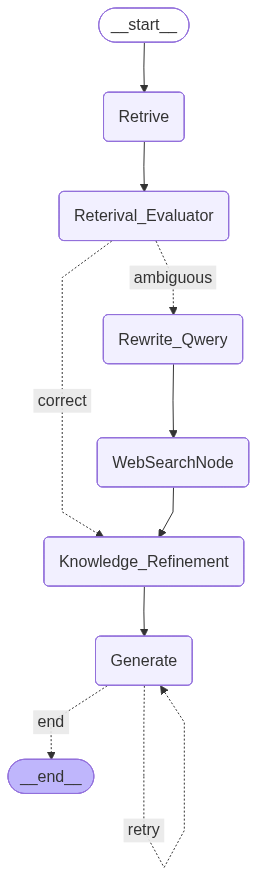

In [16]:
workflow

In [20]:
init_state={
    "user_question":"ai news of this week and tell me about transformer models ?",
    "curr_iter": 0,
    "max_iter": 3
    }
res=workflow.invoke(init_state)

retriver fxn has been caleed 
the retrival evaluation node has been called 
the out of eval llm  2
the out of eval llm  0
the out of eval llm  0
the out of eval llm  0
the eval score are [2, 0, 0, 0]
in the rewrite qwery node
in the web search node
in the knowledge refinement node
the sentence is Your daily AI news digest for May 16, 2026 — model releases, product launches, and industry updates from the leading AI labs. and the relevance is False
the sentence is Stay current with the biggest AI moves of letest ai news May 2026 — OpenAI, Google & Meta made game-changing announcements this week. and the relevance is False
the sentence is [5/7/2026] World Models Can Change Everything – World models aim to advance AI from mere pattern recognition to understanding and interacting Wondering what's happening in the AI world? and the relevance is False
the sentence is Here are the latest AI breakthroughs and news that are shaping the world around us! and the relevance is False
generate node fx

In [21]:
res

{'user_question': 'ai news of this week and tell me about transformer models ?',
 'relivent_chunks': [Document(id='abedd3bd-ce78-4329-ad4e-95acd8f6d5fa', metadata={'producer': 'Adobe PDF Services', 'creator': 'Microsoft® Word 2019', 'creationdate': '2026-04-15T06:07:42+00:00', 'author': 'Un-named', 'moddate': '2026-04-15T06:07:46+00:00', 'source': './Documents\\Code_Agent_Final_Roadmap.pdf.pdf', 'total_pages': 32, 'page': 15, 'page_label': '16'}, page_content='9.1 Orchestrator Agent \nThe Orchestrator is the central project manager. It never generates code itself — it only plans, delegates, and \nmonitors. \n \nAttribute Detail \nFramework CrewAI Crew Manager + custom Python state machine \nModel GPT-4o (with function calling enabled) \nTrigger User submits a task via the API or IDE \nResponsibilities Initialize job, invoke agents in sequence, pass context between agents, monitor retries, update job \nstate, stream progress to UI \nTools Redis publisher (publish tasks), PostgreSQL writ